In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
#data upload and copying
df = pd.read_csv("C:\\Users\\zeynep\\Desktop\\titanic-survival-prediction\\data\\Titanic-Dataset.csv")
df_copy = df.copy() 

In [3]:
#Size of data-columns-Overview. Data types.- numerical properties-null value check 
df_copy.head()
df_copy.shape
df_copy.columns
df_copy.info()
df_copy.describe()
df_copy.isnull().sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

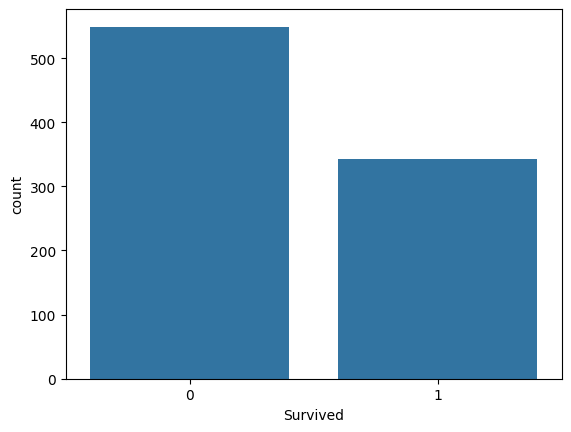

In [4]:
#target distribution-We used a countplot because we were checking for binary distribution.
sns.countplot(x="Survived", data=df_copy)

<Axes: xlabel='Survived', ylabel='count'>

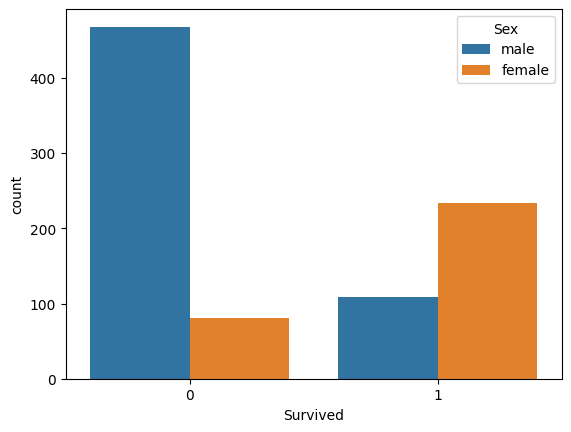

In [5]:
sns.countplot(x="Survived", hue="Sex", data=df_copy) #distribution by gender

Text(0.5, 1.0, 'Survival distribution by Pclass')

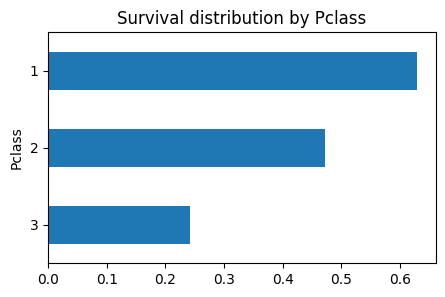

In [6]:
df_copy.groupby("Pclass")["Survived"].mean().sort_values().plot(kind="barh",figsize=(5,3))
plt.title("Survival distribution by Pclass")

Text(0.5, 1.0, 'Survival distribution by Age')

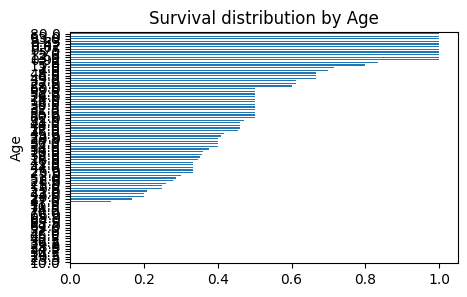

In [7]:
df_copy.groupby("Age")["Survived"].mean().sort_values().plot(kind="barh",figsize=(5,3))
plt.title("Survival distribution by Age")

Text(0.5, 1.0, 'Survival distribution by Embarked')

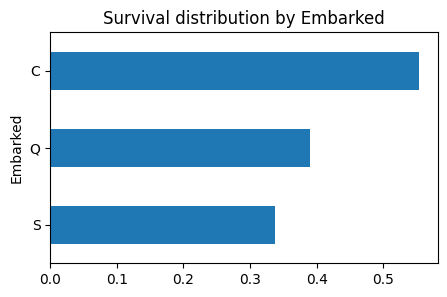

In [8]:
df_copy.groupby("Embarked")["Survived"].mean().sort_values().plot(kind="barh",figsize=(5,3))
plt.title("Survival distribution by Embarked")

<Axes: xlabel='Fare', ylabel='Count'>

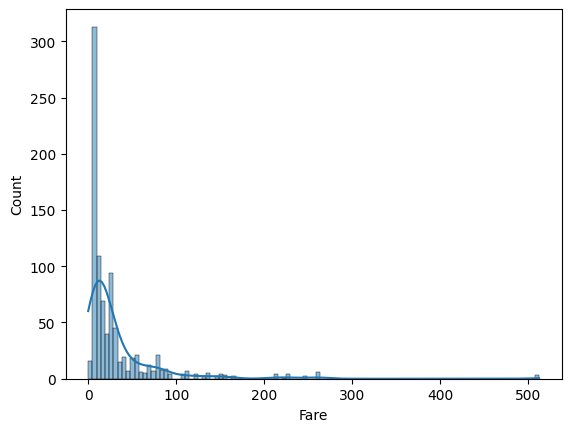

In [9]:
sns.histplot(df["Fare"], kde=True) #main data check for skew to the right

<Axes: xlabel='Fare', ylabel='Count'>

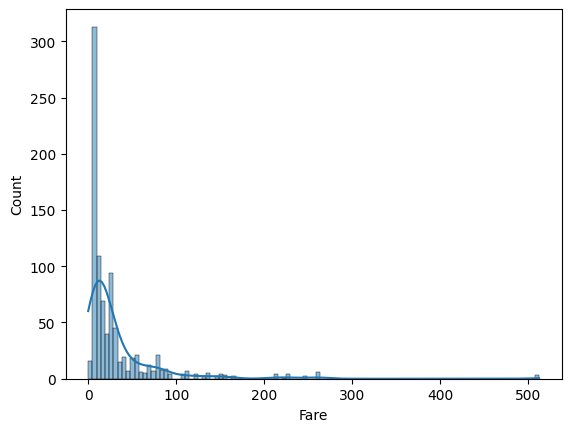

In [10]:
sns.histplot(df_copy["Fare"], kde=True) #If there is a long queue to the right → apply log

In [11]:
df_copy["Fare"] = np.log1p(df_copy["Fare"]) #log transform of skewed numbers


<Axes: xlabel='Fare', ylabel='Count'>

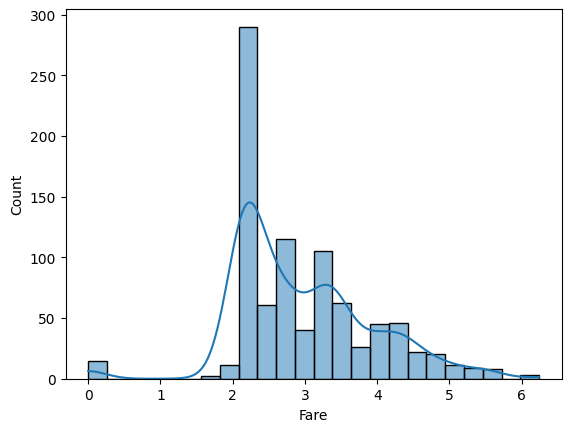

In [12]:
sns.histplot(df_copy["Fare"], kde=True)

In [13]:
corr = df_copy.corr(numeric_only=True)
corr["Survived"].sort_values(ascending=False).head(10) #Correlation analysis is mainly useful for numerical variables. 
#Since many features in this dataset are categorical, additional analysis using grouping and visualization is required to better understand their relationship with the target variable.

Survived       1.000000
Fare           0.329862
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

In [14]:
df_copy.groupby("Sex")["Survived"].mean() #survivors by gender

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [15]:
df_copy.groupby(["Pclass","Sex"])["Survived"].mean() #survivors by pclass and gender

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

In [16]:
df_copy["AgeGroup"] = pd.cut(df_copy["Age"], bins = [0,12,18,35,60,100]) #survivors by age group
df_copy.groupby("AgeGroup")["Survived"].mean()

C:\Users\zeynep koç\AppData\Local\Temp\ipykernel_22160\603552627.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_copy.groupby("AgeGroup")["Survived"].mean()


AgeGroup
(0, 12]      0.579710
(12, 18]     0.428571
(18, 35]     0.382682
(35, 60]     0.400000
(60, 100]    0.227273
Name: Survived, dtype: float64

In [17]:
df_copy.drop(["PassengerId", "Ticket"] , axis=1, inplace=True) #delete unnecessary columns

In [18]:
df_copy.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Cabin', 'Embarked', 'AgeGroup'],
      dtype='object')

In [19]:
df_copy["Title"] = df_copy["Name"].str.extract(r' ([A-Za-z]+)\.', expand=False)#Titles were separated from the name column.

In [20]:
df_copy["Title"] = df_copy["Title"].replace([
    "Lady", "Countess", "Capt", "Col", "Don", "Dr",
    "Major", "Rev", "Sir", "Jonkheer", "Dona"
], "Rare")#titles were specified

In [21]:

df_copy.drop(["Name"] , axis=1, inplace=True)#The name column was deleted.

In [22]:
df_copy.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked', 'AgeGroup', 'Title'],
      dtype='object')

In [23]:
df_copy[["Title"]].head()

,Title
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr


In [24]:
df_copy["HasCabin"] = df_copy["Cabin"].notnull().astype(int)
df_copy.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked', 'AgeGroup', 'Title', 'HasCabin'],
      dtype='object')

In [25]:
df_copy["HasCabin"] 

0      0
1      1
2      0
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: HasCabin, Length: 891, dtype: int64

In [26]:
df_copy.drop("Cabin", axis=1, inplace=True)

In [27]:
df_copy.isnull().sum() #missing data

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
AgeGroup    177
Title         0
HasCabin      0
dtype: int64

In [28]:
df_copy["Embarked"].fillna(df_copy["Embarked"].mode()[0], inplace=True) # Fill missing values with the most frequent value in the Embarked column.

C:\Users\zeynep koç\AppData\Local\Temp\ipykernel_22160\3933453333.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy["Embarked"].fillna(df_copy["Embarked"].mode()[0], inplace=True) # Fill missing values with the most frequent value in the Embarked column.


In [29]:
df_copy["Age"] = df_copy.groupby("Title")["Age"].transform(lambda x: x.fillna(x.median()))

In [30]:
df_copy["AgeGroup"] = pd.cut(df_copy["Age"], bins = [0,12,18,35,60,100])

In [31]:
df_copy.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
AgeGroup    0
Title       0
HasCabin    0
dtype: int64

In [32]:
df_copy["Sex"] = df_copy["Sex"].map({"male":0, "female":1}) #binary encoding → because there are only 2 values.

In [33]:
df_copy = pd.get_dummies(df_copy, columns=["Embarked"], drop_first=True) #3 categories → One-Hot Encoding.

In [34]:
df_copy = pd.get_dummies(df_copy, columns=["Title"], drop_first=True)

In [35]:
df_copy.AgeGroup

0      (18, 35]
1      (35, 60]
2      (18, 35]
3      (18, 35]
4      (18, 35]
         ...   
886    (18, 35]
887    (18, 35]
888    (18, 35]
889    (18, 35]
890    (18, 35]
Name: AgeGroup, Length: 891, dtype: category
Categories (5, interval[int64, right]): [(0, 12] < (12, 18] < (18, 35] < (35, 60] < (60, 100]]

In [36]:
df_copy = pd.get_dummies(df_copy, columns=["AgeGroup"], drop_first=True) # AgeGroup contains interval-based categories, not raw numeric values.

In [37]:
df_copy["FamilySize"] = df_copy["SibSp"] + df_copy["Parch"] + 1 #How many people did the passenger travel with? Sibling / Spouse - Parent / Child and Himself/Herself

In [38]:
df_copy["IsAlone"] = (df_copy["FamilySize"]== 1).astype(int) #lonely ones

In [39]:
df_copy["FarePerPerson"] = df_copy["Fare"] / df_copy["FamilySize"]

In [40]:
#Feature – Target separation
X = df_copy.drop("Survived", axis=1)
y = df_copy["Survived"] #target

In [41]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [43]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler() #Scaling
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
#train a model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred= model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score, classification_report

In [48]:
accuracy_score(y_test,y_pred)

0.8212290502793296

In [49]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       105
           1       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [50]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

In [52]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [53]:
print("LogisticRegression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

LogisticRegression
Accuracy: 0.8212290502793296
              precision    recall  f1-score   support

           0       0.84      0.86      0.85       105
           1       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [54]:
from sklearn.tree import DecisionTreeClassifier

In [55]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_raw, y_train)
y_pred_dt = dt.predict(X_test_raw)

In [56]:
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       105
           1       0.75      0.78      0.77        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.80      0.80       179



In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_raw, y_train)
y_pred_rf = rf.predict(X_test_raw)

In [59]:
print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.8268156424581006
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       105
           1       0.79      0.80      0.79        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [64]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [62]:
results = []

In [65]:
# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr)
})


In [66]:
# Decision Tree
results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1 Score": f1_score(y_test, y_pred_dt)
})

In [67]:
# Random Forest
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf)
})

In [68]:
comparison_df = pd.DataFrame(results)
print(comparison_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.821229   0.791667  0.770270  0.780822
1        Decision Tree  0.804469   0.753247  0.783784  0.768212
2        Random Forest  0.826816   0.786667  0.797297  0.791946


In [71]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_rf))

[[86 19]
 [16 58]]
[[90 15]
 [17 57]]
[[89 16]
 [15 59]]


In [73]:
#threshold
y_prob = rf.predict_proba(X_test_raw)[:, 1]

y_pred_new = (y_prob > 0.4).astype(int)

In [74]:
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[87 18]
 [14 60]]
              precision    recall  f1-score   support

           0       0.86      0.83      0.84       105
           1       0.77      0.81      0.79        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



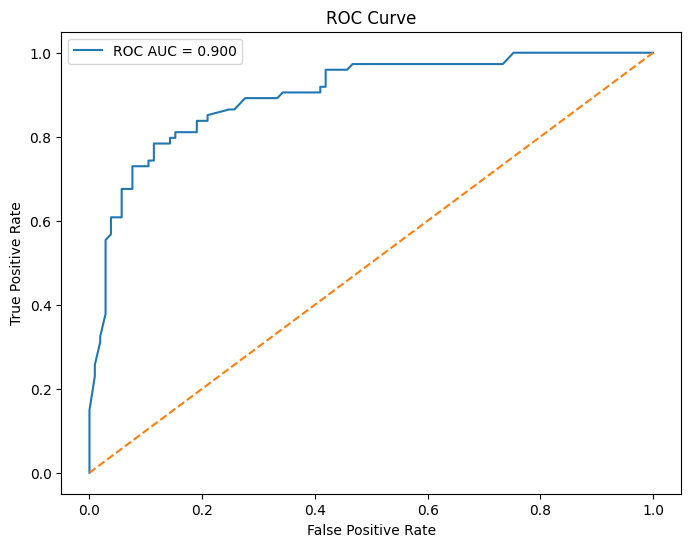

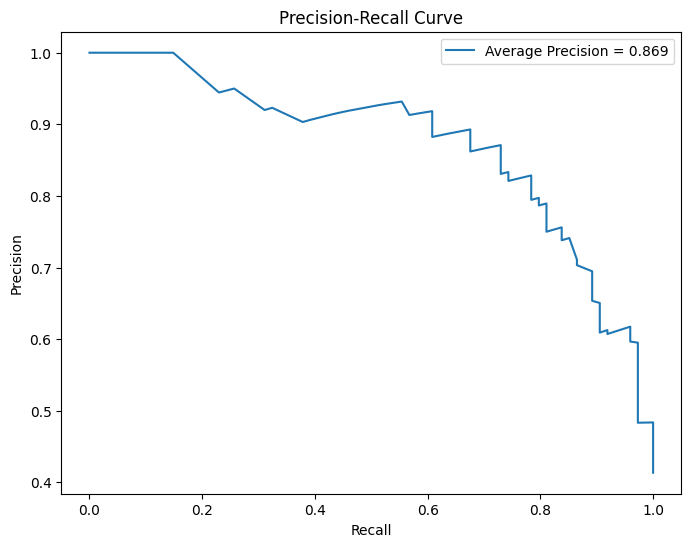

In [ ]:


from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

# Positive class probability for Random Forest
y_prob = rf.predict_proba(X_test_raw)[:, 1]

# ROC
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"Average Precision = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [79]:
from sklearn.metrics import confusion_matrix, classification_report

for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    
    # threshold
    y_pred_temp = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_temp)

    print(f"\n===== Threshold: {t} =====")
    print("Confusion Matrix:")
    print(cm)
    print("Accuracy:", round(accuracy_score(y_test, y_pred_temp), 3))
    print("Precision:", round(precision_score(y_test, y_pred_temp), 3))
    print("Recall:", round(recall_score(y_test, y_pred_temp), 3))
    print("F1 Score:", round(f1_score(y_test, y_pred_temp), 3))
    
    #print(f"\n===== Threshold: {t} =====")
    
    # confusion matrix
    #print("Confusion Matrix:")
    #print(confusion_matrix(y_test, y_pred_temp))
    
    # classification report
    #print("Classification Report:")
    #print(classification_report(y_test, y_pred_temp))


===== Threshold: 0.3 =====
Confusion Matrix:
[[83 22]
 [12 62]]
Accuracy: 0.81
Precision: 0.738
Recall: 0.838
F1 Score: 0.785

===== Threshold: 0.35 =====
Confusion Matrix:
[[85 20]
 [13 61]]
Accuracy: 0.816
Precision: 0.753
Recall: 0.824
F1 Score: 0.787

===== Threshold: 0.4 =====
Confusion Matrix:
[[87 18]
 [14 60]]
Accuracy: 0.821
Precision: 0.769
Recall: 0.811
F1 Score: 0.789

===== Threshold: 0.45 =====
Confusion Matrix:
[[89 16]
 [14 60]]
Accuracy: 0.832
Precision: 0.789
Recall: 0.811
F1 Score: 0.8

===== Threshold: 0.5 =====
Confusion Matrix:
[[89 16]
 [15 59]]
Accuracy: 0.827
Precision: 0.787
Recall: 0.797
F1 Score: 0.792


In [ ]:
#The threshold was chosen as 0.35 because it keeps the recall rate high while maintaining an acceptable level of false positives.
results = []

for t in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred_temp = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    results.append({
        "Threshold": t,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Accuracy": round(accuracy_score(y_test, y_pred_temp), 3),
        "Precision": round(precision_score(y_test, y_pred_temp), 3),
        "Recall": round(recall_score(y_test, y_pred_temp), 3),
        "F1": round(f1_score(y_test, y_pred_temp), 3)
    })

threshold_df = pd.DataFrame(results)
print(threshold_df)

   Threshold  TN  FP  FN  TP  Accuracy  Precision  Recall     F1
0       0.30  83  22  12  62     0.810      0.738   0.838  0.785
1       0.35  85  20  13  61     0.816      0.753   0.824  0.787
2       0.40  87  18  14  60     0.821      0.769   0.811  0.789
3       0.45  89  16  14  60     0.832      0.789   0.811  0.800
4       0.50  89  16  15  59     0.827      0.787   0.797  0.792


In [81]:
#Why does the model make such a prediction?
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False)

Age                   0.162338
Fare                  0.147789
FarePerPerson         0.140858
Title_Mr              0.125058
Sex                   0.097438
Pclass                0.054523
Title_Mrs             0.050420
HasCabin              0.033883
FamilySize            0.031504
Title_Miss            0.030459
SibSp                 0.026238
Embarked_S            0.022126
Parch                 0.020379
AgeGroup_(18, 35]     0.011774
IsAlone               0.009218
AgeGroup_(35, 60]     0.008889
Embarked_Q            0.008532
Title_Rare            0.008365
AgeGroup_(12, 18]     0.006366
AgeGroup_(60, 100]    0.003158
Title_Ms              0.000356
Title_Mlle            0.000202
Title_Mme             0.000129
dtype: float64

In [84]:
#Which one is the model predicting incorrectly?
errors = X_test_raw.copy()
errors["y_true"] = y_test
errors["y_pred"] = y_pred_new

wrong = errors[errors["y_true"] != errors["y_pred"]]
print(wrong)

     Pclass  Sex   Age  SibSp  Parch      Fare  HasCabin  Embarked_Q  \
39        3    1  14.0      1      0  2.504848         0       False   
621       1    0  42.0      1      0  3.980694         1       False   
447       1    0  34.0      0      0  3.316003         0       False   
192       3    1  19.0      1      0  2.180892         0       False   
673       2    0  31.0      0      0  2.639057         0       False   
396       3    1  31.0      0      0  2.180892         0       False   
235       3    1  21.0      0      0  2.145931         0       False   
204       3    0  18.0      0      0  2.202765         0       False   
362       3    1  45.0      0      1  2.737881         0       False   
67        3    0  19.0      0      0  2.214661         0       False   
659       1    0  58.0      0      2  4.738608         1       False   
772       2    1  57.0      0      0  2.442347         1       False   
312       2    1  26.0      1      1  3.295837         0       F

In [85]:
df_copy["Sex_Pclass"] = df_copy["Sex"] * df_copy["Pclass"]

In [86]:
X = df_copy.drop("Survived", axis=1)
y = df_copy["Survived"]

In [87]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [88]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_raw, y_train)

y_prob = rf.predict_proba(X_test_raw)[:, 1]

In [89]:
y_pred_new = (y_prob >= 0.35).astype(int)

In [90]:
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[85 20]
 [14 60]]
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       105
           1       0.75      0.81      0.78        74

    accuracy                           0.81       179
   macro avg       0.80      0.81      0.81       179
weighted avg       0.81      0.81      0.81       179



In [92]:
from sklearn.model_selection import GridSearchCV

In [93]:


param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 10, None],
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train_raw, y_train)

print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 100}


In [94]:
rf_best = RandomForestClassifier(
    max_depth=5,
    n_estimators=100,
    random_state=42
)

rf_best.fit(X_train_raw, y_train)

y_prob = rf_best.predict_proba(X_test_raw)[:, 1]
y_pred_new = (y_prob >= 0.35).astype(int)

In [95]:
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[88 17]
 [15 59]]
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       105
           1       0.78      0.80      0.79        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179



In [ ]:
#feature importance
importance = pd.Series(rf_best.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

Title_Mr              0.169990
Sex                   0.167329
Sex_Pclass            0.153469
FarePerPerson         0.085048
Fare                  0.077537
Pclass                0.068790
Title_Mrs             0.052700
Age                   0.048479
FamilySize            0.038262
Title_Miss            0.033465
HasCabin              0.033244
SibSp                 0.020815
Parch                 0.011211
Embarked_S            0.009683
IsAlone               0.006584
Title_Rare            0.004991
AgeGroup_(18, 35]     0.004941
Embarked_Q            0.004607
AgeGroup_(35, 60]     0.004102
AgeGroup_(12, 18]     0.002755
AgeGroup_(60, 100]    0.001590
Title_Mlle            0.000303
Title_Mme             0.000084
Title_Ms              0.000020
dtype: float64


In [97]:
#delete useless columns
drop_cols = [
    "AgeGroup_(18, 35]",
    "AgeGroup_(35, 60]",
    "AgeGroup_(12, 18]",
    "AgeGroup_(60, 100]",
    "Title_Mlle",
    "Title_Mme",
    "Title_Ms",
]

df_copy = df_copy.drop(columns=drop_cols)

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [100]:
rf = RandomForestClassifier(
    max_depth=5,
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [101]:
y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.35).astype(int)

In [102]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[88 17]
 [15 59]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       105
           1       0.78      0.80      0.79        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179

